### **FORMULA 1 ANALYSIS**


**Data Description**

The datasets used in this project include:

- Circuits: Information about the racing circuits.
- Constructor Results: Results of each constructor in the races.
- Constructor Standings: Standings of constructors in the championship.
- Constructors: Information about constructors.
- Driver Standings: Standings of drivers in the championship.
- Drivers: Information about drivers.
- Lap Times: Lap times for each driver in each race.
- Pit Stops: Data on pit stops during races.
- Qualifying: Qualifying results for drivers.
- Races: Details of each race.
- Results: Results of each race.
- Seasons: Information about the seasons.
- Sprint Results: Results from sprint races.
- Status: Status of drivers in each race.


In [5]:
# import libraries
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import numpy as np

In [6]:
# Load the datasets
circuits = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/circuits.csv')
constructor_results = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/constructor_results.csv')
constructor_standings = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/constructor_standings.csv')
constructors = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/constructors.csv')
driver_standings = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/driver_standings.csv')
drivers = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/drivers.csv')
lap_times = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/lap_times.csv')
pit_stops = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/pit_stops.csv')
qualifying = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/qualifying.csv')
races = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/races.csv')
results = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/results.csv')
seasons = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/seasons.csv')
sprint_results = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/sprint_results.csv')
status = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/status.csv')

**RACE WINS BY DRIVER**

Find out which top 5 drivers have won the most races.

In [7]:
# Filter to get race winners
winners = results[results['positionOrder'] == 1]

# Count wins for each driver
wins_each = winners.groupby('driverId').size().reset_index(name='wins')

# Merge with driver names
wins_names = pd.merge(wins_each, drivers[['driverId', 'surname']], on='driverId')
print(wins_names.sort_values(by='wins', ascending=False).head())

     driverId  wins     surname
0           1   105    Hamilton
15         30    91  Schumacher
107       830    63  Verstappen
11         20    53      Vettel
29        117    51       Prost


<Figure size 1000x600 with 0 Axes>

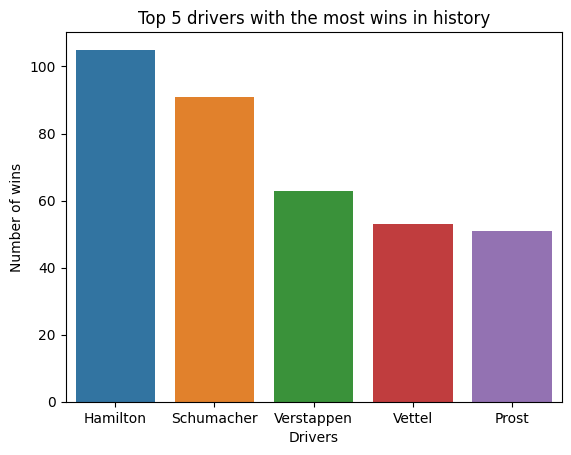

<Figure size 1000x600 with 0 Axes>

In [8]:
top_5 = wins_names.sort_values(by='wins', ascending=False).head()
names = top_5['surname'].head()
top_5_wins = top_5['wins'].head()

# Bar chart showing top 5 drivers with the most wins
sns.barplot(x=names, y=top_5_wins)

# labels
plt.title('Top 5 drivers with the most wins in history')
plt.xlabel("Drivers")
plt.ylabel("Number of wins")
plt.figure(figsize=(10,6))

**DRIVER WINS OVER TIME**

Visualize the number of wins for the Lewis Hamilton

    year   surname  wins  cumulative_wins
0   2007  Hamilton     4                4
1   2008  Hamilton     5                9
2   2009  Hamilton     2               11
3   2010  Hamilton     3               14
4   2011  Hamilton     3               17
5   2012  Hamilton     4               21
6   2013  Hamilton     1               22
7   2014  Hamilton    11               33
8   2015  Hamilton    10               43
9   2016  Hamilton    10               53
10  2017  Hamilton     9               62
11  2018  Hamilton    11               73
12  2019  Hamilton    11               84
13  2020  Hamilton    11               95
14  2021  Hamilton     8              103
15  2024  Hamilton     2              105


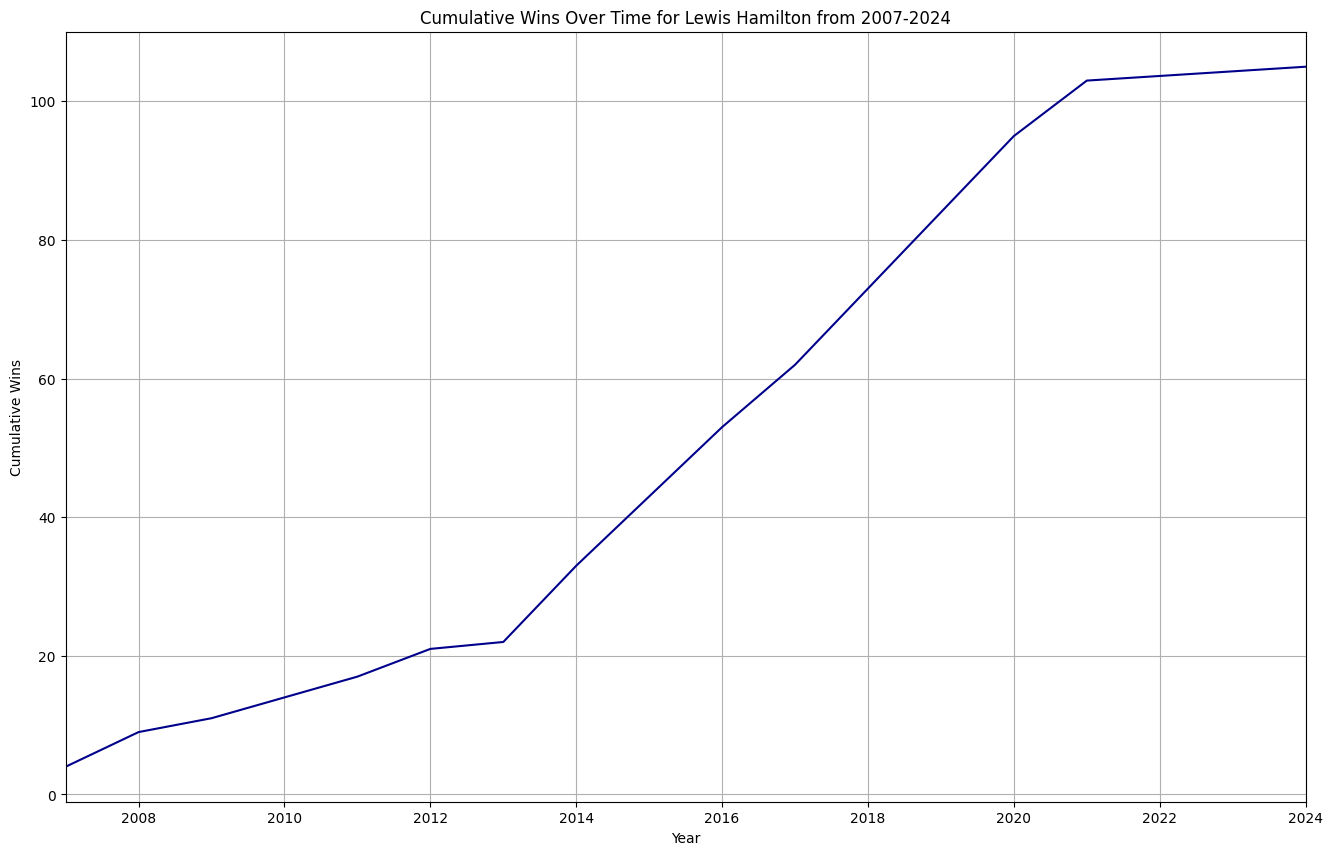

In [9]:
# Merge winners with race data to get the year
winners_year = winners.merge(races[['raceId', 'year']], on='raceId')

# Merge with driver data to get driver names
winner_names = winners_year.merge(drivers[['driverId', 'surname']], on='driverId')

# Filter for Lewis Hamilton
lh = winner_names[winner_names['surname']=='Hamilton']

# Group by year and driver to count wins per year
wins_per_year = lh.groupby(['year', 'surname']).size().reset_index(name='wins')

# Create a cumulative sum of wins over time for each driver
wins_per_year['cumulative_wins'] = wins_per_year.groupby('surname')['wins'].cumsum()
print(wins_per_year)

# Plot the data as a line chart
plt.figure(figsize=(16, 10))
plt.plot(wins_per_year['year'], wins_per_year['cumulative_wins'], color='darkblue')
plt.title('Cumulative Wins Over Time for Lewis Hamilton from 2007-2024')
plt.xlabel('Year')
plt.ylabel('Cumulative Wins')
plt.xlim(2007, 2024)
plt.grid(True)

**RACE WINS BY NATIONALITY**

Pie chart to show the percentages of 1st place podiums by drivers' nationalities.

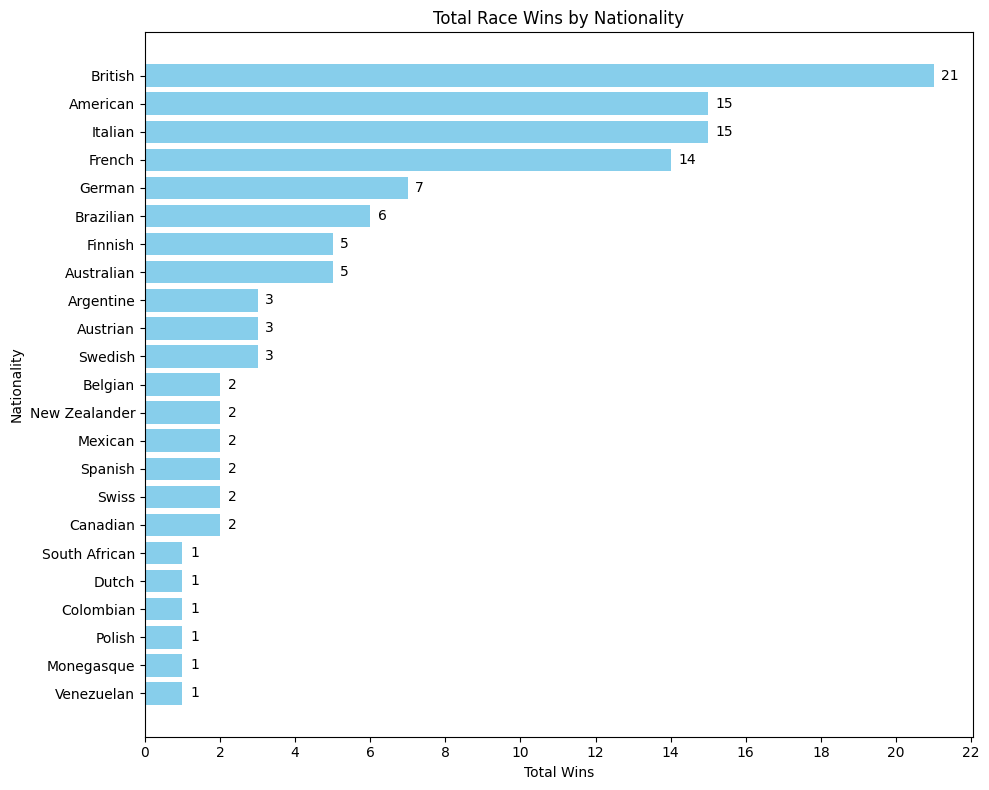

In [10]:
# Filter to get race winners
winners = results[results['positionOrder'] == 1]

# Count wins for each driver
wins_each = winners.groupby('driverId').size().reset_index(name='wins')

# Merge with driver name and nationality
wins_names = pd.merge(wins_each, drivers[['driverId', 'nationality']], on='driverId')

# Count wins for each nationality
wins_nat = wins_names.groupby('nationality').size().reset_index(name='total wins')
wins_nat.sort_values(by='total wins', ascending=False).head()

# Bar chart of wins by nationality
wins_nat_sorted = wins_nat.sort_values(by='total wins', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
bars = plt.barh(wins_nat_sorted['nationality'], wins_nat_sorted['total wins'], color='skyblue')

# Annotate each bar with the number of wins
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2,bar.get_y() + bar.get_height()/2, str(int(width)), va='center')   
    
plt.xlabel('Total Wins')
plt.xticks(np.arange(0, 23, 2))
plt.ylabel('Nationality')
plt.title('Total Race Wins by Nationality')
plt.tight_layout()
plt.show()

**Constructor Championship Performance**

Analyze which constructor has the most podiums (1st-3rd place) over time.

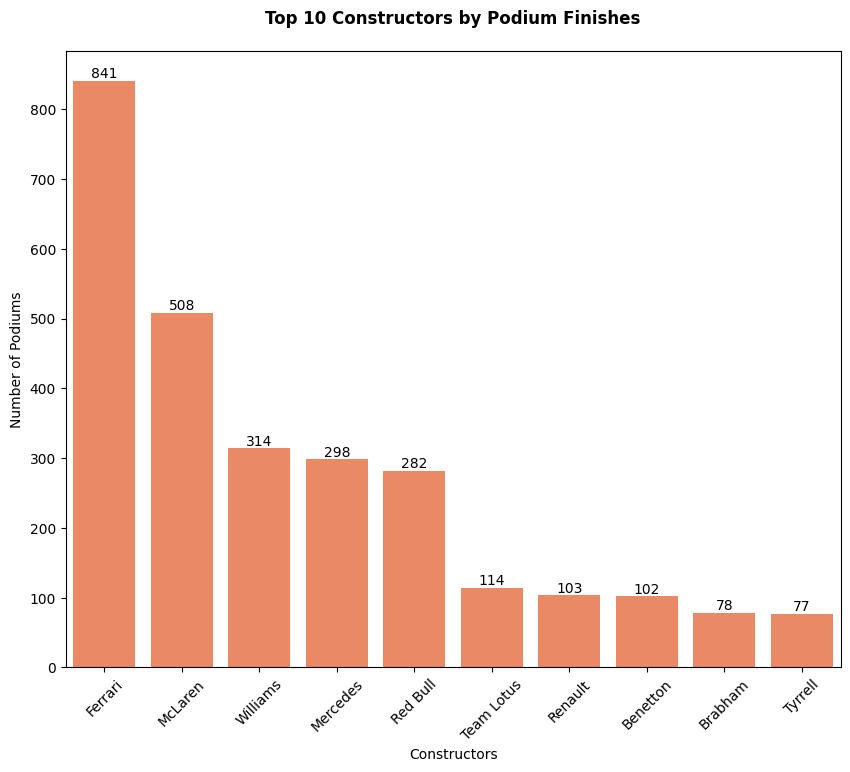

In [11]:
# get all of the podium results
podiums = results[results['positionOrder'].isin([1,2,3])]

# count the podium finishes by constructorId
constructor_finish = podiums.groupby('constructorId').size().reset_index(name='podiums')

# get constructors names based off their id
constructor_name = pd.merge(constructor_finish, constructors[['constructorId', 'name']], on='constructorId')

# bar chart of top 10 teams
constructor_sorted = constructor_name.sort_values(by='podiums', ascending=False).head(10)
plt.figure(figsize=(10, 8))
sns.barplot(x=constructor_sorted['name'], y = constructor_sorted['podiums'], color='coral')
plt.xlabel('Constructors')
plt.ylabel("Number of Podiums")
plt.xticks(rotation=45)
plt.title('Top 10 Constructors by Podium Finishes',fontdict={'fontsize': 12, 'fontweight': 800}, pad=20)

for i in plt.gca().patches:
    h = i.get_height()
    plt.annotate(f'{h:.0f}', xy=(i.get_x() + i.get_width() / 2, h), ha='center', va='bottom')

**Performance of 2019 Rookie Drivers Over their Careers**

Visualize the performance of George Russell, Lando Norris and Alex Albon overtime from all of their seasons in F1 since they started in 2019.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

Text(0.5, 1.0, '2019 Rookies Performance Over Time')

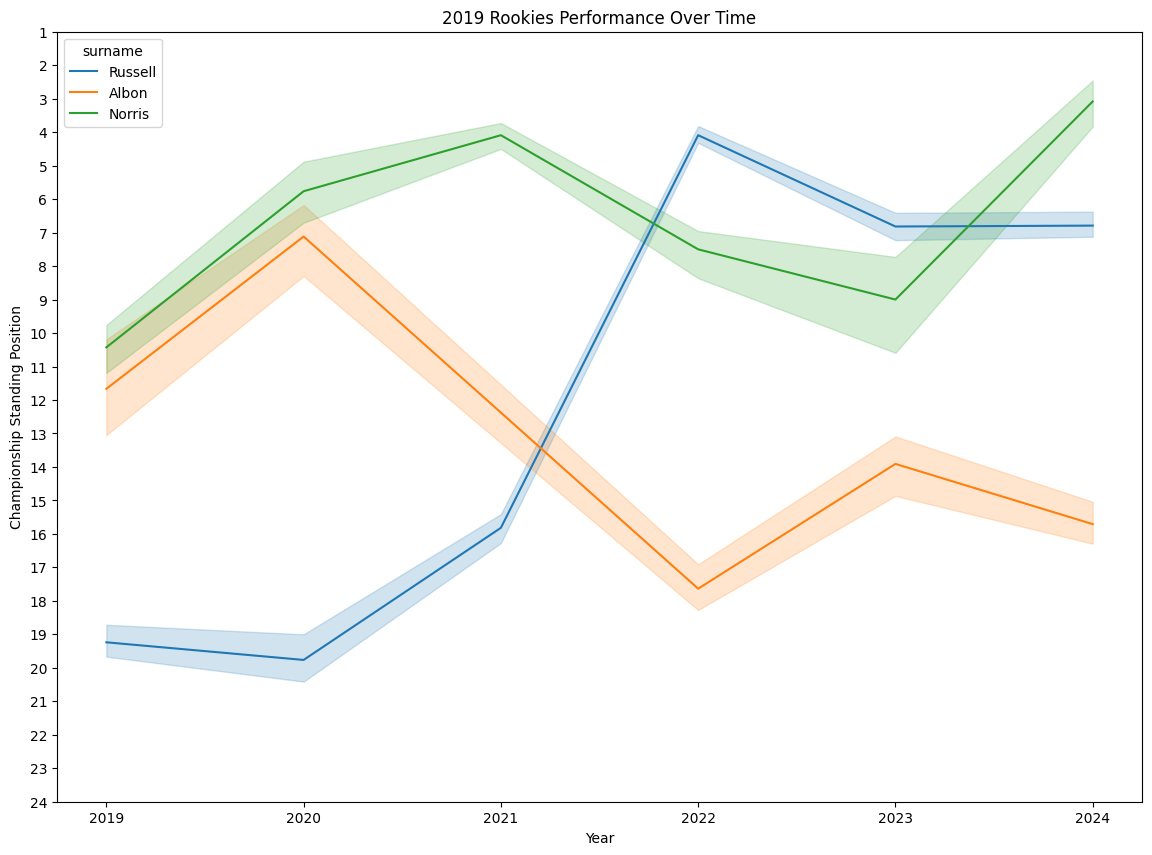

In [12]:
# merge data to get driver standing by year
standing = pd.merge(driver_standings, drivers[['driverId', 'surname']], on = 'driverId')
standing = pd.merge(standing, races[['raceId', 'year']], on = 'raceId')
#print(standing.head())

# filter for 2019 rookies
names = ['Norris','Albon', 'Russell']
performance = standing[standing['surname'].isin(names)]
performance = performance[performance['year'] >= 2019]

# graph data
plt.figure(figsize=(14,10))
sns.lineplot(data=performance, x=performance['year'], y=performance['position'], hue='surname')
plt.gca().invert_yaxis()
plt.yticks(range(1,25))
plt.xlabel('Year')
plt.ylabel('Championship Standing Position')
plt.title("2019 Rookies Performance Over Time")

**Pole Position and Race Outcome Correlation**

Analyze how often drivers who qualify for pole position end up winning the race. Calculate the probability of winning based on starting from pole position.

In [13]:
# filter out pole positions from results
pole = results[results['grid'] == 1]

# filter out to determine where drivers on pole position won the race
wins = pole[pole['positionOrder'] == 1]
#print(wins.head())

# calculate the probability of winning from pole position
prob = len(wins) / len(pole)

# Step 4: Print the result
print(f"Probability of winning race from pole position: {prob:.2%}")

Probability of winning race from pole position: 42.34%


**Predicting Podium Finishes**

Predict whether a driver will finish on a podium based on their grid position and race.

Confusion Matrix:
[[4521  151]
 [ 548  132]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      4672
           1       0.47      0.19      0.27       680

    accuracy                           0.87      5352
   macro avg       0.68      0.58      0.60      5352
weighted avg       0.84      0.87      0.85      5352



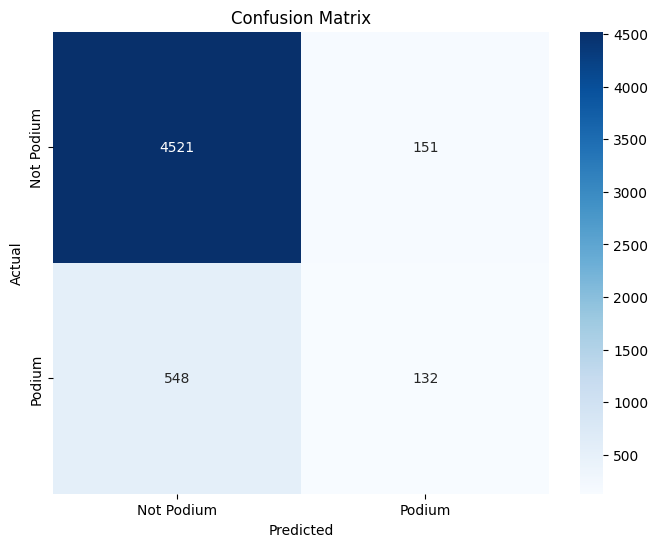

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Merge results with drivers to get driver names
data = pd.merge(results, drivers[['driverId', 'surname']], on='driverId')

# Create a binary column for podium finishes (1 if positionOrder is 1, 2, or 3, else 0)
data['podium'] = np.where(data['positionOrder'].isin([1, 2, 3]), 1, 0)

# Select relevant features for the model
features = data[['grid', 'raceId', 'driverId']]
target = data['podium']

# Encode categorical variables (e.g., driverId and raceId) if necessary
features = pd.get_dummies(features, columns=['driverId', 'raceId'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Create and fit the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize the confusion matrix
labels = ['Not Podium', 'Podium']
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
